                    QUESTION 1: FINDING OUT SEASONAL PATTERNS USING YEAR-ON-YEAR DATA

                            LIBRARIES: PANDAS, MATPLOTLIB, SEABORN, NUMPY
                            
                            DATASETS: DAILY_YOY.CSV, WEEKLY.CSV


# APPROACH :
- Plotted date-wise Year-On-Year data to capture any repeating seasonal patterns over the years (2012-2015)
- Plotted weekly Year-On-Year data to find if any weekdays have an impact on the prices

In [1]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

c:\Users\rachn\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
## Loading daily and weekly data

df_yoy = pd.read_csv('daily_yoy.csv')
df_weekly = pd.read_csv("Weekday.csv")

In [3]:
#contains year, day of year, month and price
df_yoy.head()



,YEAR,DAY_OF_YEAR,MONTH,PRICE
0,2012,1,1,99
1,2012,2,1,95
2,2012,3,1,96
3,2012,4,1,95
4,2012,5,1,93


In [4]:
# Contains year, weekday and the price
df_weekly.head()

,YEAR,WEEKDAY,PRICE
0,2012,Monday,81
1,2012,Monday,83
2,2012,Monday,83
3,2012,Monday,83
4,2012,Monday,84


In [5]:
# uppercase column names — normalize
df_yoy.columns     = df_yoy.columns.str.lower()
df_weekly.columns = df_weekly.columns.str.lower()

                                    PLOTTING DAILY YOY TREND  

In [6]:
#defining years, colors to use, month labels and days whene month starts

YEARS        = [2012, 2013, 2014, 2015]   # Discarded 2016 
COLORS       = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']  
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
MONTH_START_DAYS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

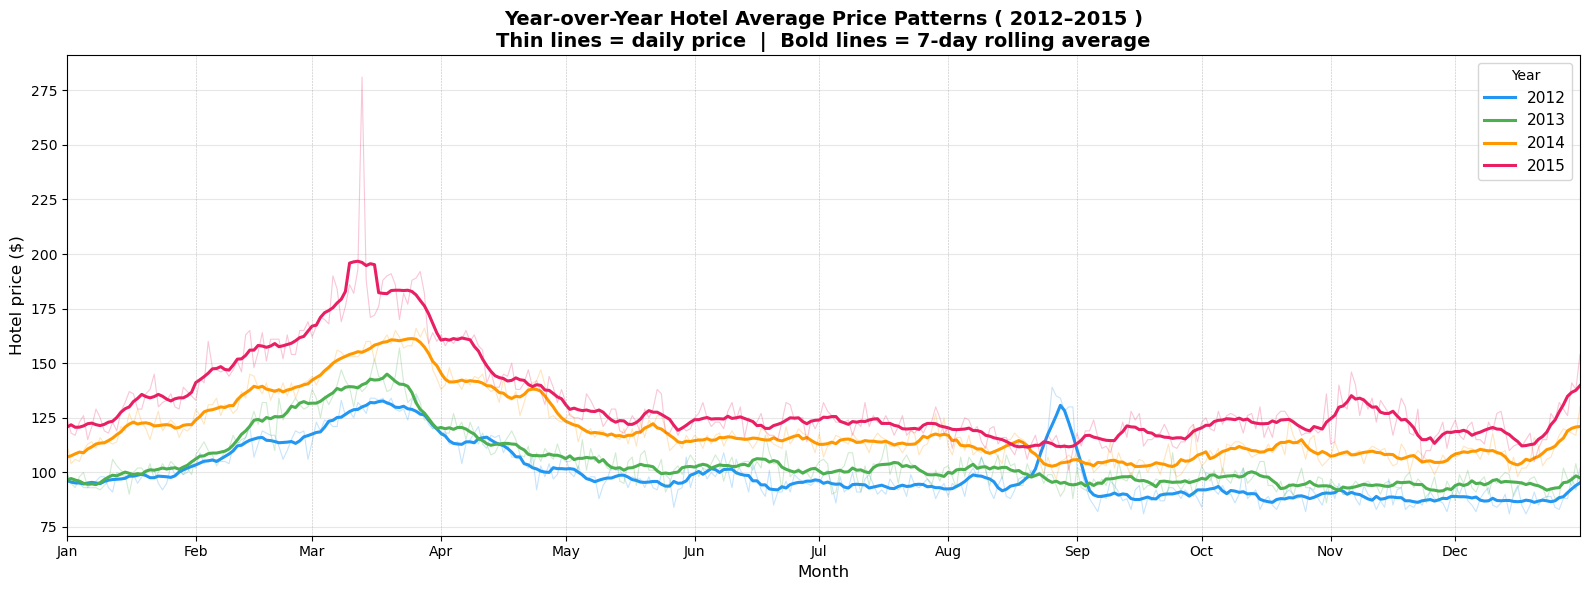

In [9]:
#CHART 1 
fig, ax = plt.subplots(figsize=(16, 6))

for year, color in zip(YEARS, COLORS):
    yr_data = df_yoy[df_yoy['year'] == year].sort_values('day_of_year').copy()

    # plotting day of year and the price
    ax.plot(yr_data['day_of_year'], yr_data['price'],
            color=color, alpha=0.25, linewidth=0.8)

    # 7-day rolling average - to get a full idea 
    yr_data['rolling7'] = yr_data['price'].rolling(
    window=7, center=True, min_periods=1).mean()
    ax.plot(yr_data['day_of_year'], yr_data['rolling7'],
            color=color, linewidth=2.2, label=str(year))

ax.set_xticks(MONTH_START_DAYS)
ax.set_xticklabels(MONTH_LABELS, fontsize=10)
for day in MONTH_START_DAYS[1:]:
    ax.axvline(day, color='grey', linewidth=0.4, linestyle='--', alpha=0.5)


ax.set_xlim(1, 365)
ax.set_ylabel('Hotel price ($)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title('Year-over-Year Hotel Average Price Patterns ( 2012–2015 )\n'
             'Thin lines = daily price  |  Bold lines = 7-day rolling average',
             fontsize=14, fontweight='bold')
ax.legend(title='Year', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Results :

- Hotel prices follow a clear repeating seasonal pattern across all four years

- Prices peak in March–April (Spring Break) and again from December (Year End), with a  dip in mid-summer and fall

- The September 2012 anomaly (blue spike) and the March 2015 spike stand out as deviations/outliers from the seasonal pattern, both are investigated further in the outlier analysis

                                            WEEKLY YOY TREND

In [10]:
df_weekly['weekday'] = df_weekly['weekday'].str.strip()

# weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_weekly['weekday'] = pd.Categorical(df_weekly['weekday'], categories=weekday_order, ordered=True)

# Aggregate the prices (average) 
weekday_avg = df_weekly.groupby(['year', 'weekday'], observed=True)['price'].mean().reset_index()


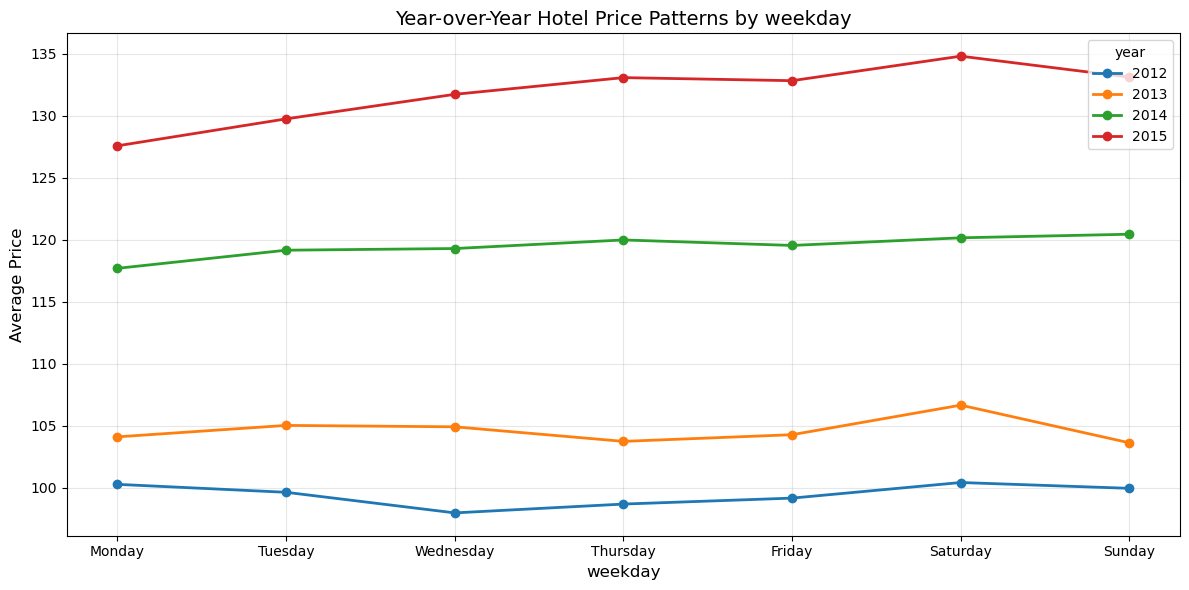

In [11]:
# CHART 2
plt.figure(figsize=(12,6))

#plotting price based on weekdays
for year, group in weekday_avg.groupby('year'):
    group = group.sort_values('weekday')
    plt.plot(group['weekday'], group['price'], marker='o', linewidth=2, label=str(year))


plt.title("Year-over-Year Hotel Price Patterns by weekday", fontsize=14)
plt.xlabel("weekday", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.legend(title="year")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Results:

- There is an almost similar trend in the weekly patterns for all the 4 years

- Prices notably start rising from Fridays with a high peak on Saturdays due to plethora of demands on the weekends